# Stage 1: Data Preprocessing
---

## 1.1: Relevant imports and fetching the data

We will import all the relevant modules that will help run this module. This includes the API for fetching the relevant stock data (yfinance in this case) amidst validation and cleaning functions, basic plotting functions, dataframes, numpy arrays and more.

In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from src import config as cf
from src.data_pipeline import fetch_stock_data, clean_data, validate_data, clean_data, save_data # cleaning functions
from src.data_pipeline import plot_stocks, plot_single_stock # plotting functions for visualisations.


# Define stock symbols and date range for data retrieval and download adjusted closing prices
stock_data = fetch_stock_data(cf.SYMBOLS, cf.START_DATE, cf.END_DATE, cf.INTERVAL)

[*********************100%***********************]  5 of 5 completed


## 1.2 Fetching and Cleaning Data

In this part of the preprocessing we will fetch out stock data from the chosen stocks. 


Please note that we will be focusing on Adjusted close prices (i.e close prices that account for corporate actions such as dividends, stock splits, rights offerings etc.)

Step 1: Fetching data will be handled by the fetch_data() function which will download data from the yfinance api selecting opening and closing prices.

Step 2: Sanity checking data by validate_data() (handling nulls, ensuring prices remain reasonable and overnight trading hasn't been affecting the market too heavily, check also for missing values or duplicate values)

Step 3: Basic Data cleaning with clean_data(). Implementing cleaning measures based on validate data results such as clipping data where overnight trading has been above 3 standard deviations from the rolling mean of 21 trading days (an average trading month) or dropping any accidental duplicate dates, filling missing data, etc.

Step 4: Saving processed data with save_data() to a CSV to be used later.

Step 5: Plotting stock data (Price (USD) for the project against Time (years))

For further information on how the relevant functions are implemented here you can see src/data_pipeline.py

No missing values detected.
No duplicate dates detected.
No negative prices detected.
Handling close-open anomalies by clipping open prices.
Cleaned data for stocks ['AMD', 'GOOGL', 'JPM', 'XOM', 'KO'] saved successfully.
Plot 1: Single Stock Plot (AMD) - Close Price vs Time


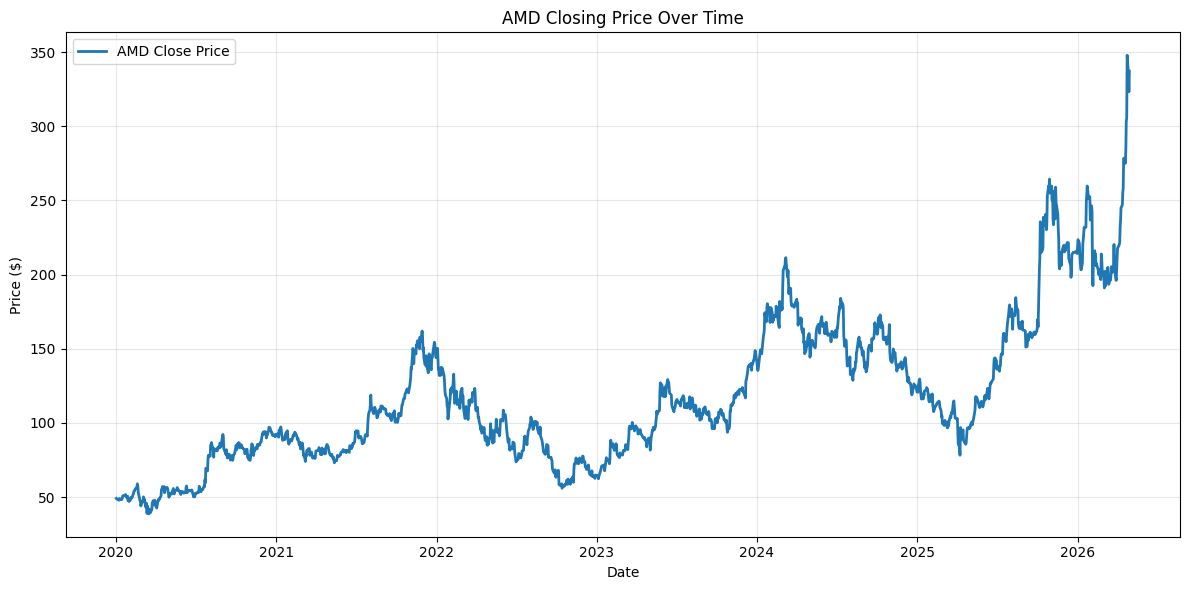

Plot 2: All Stocks Plot - Close Price vs Time


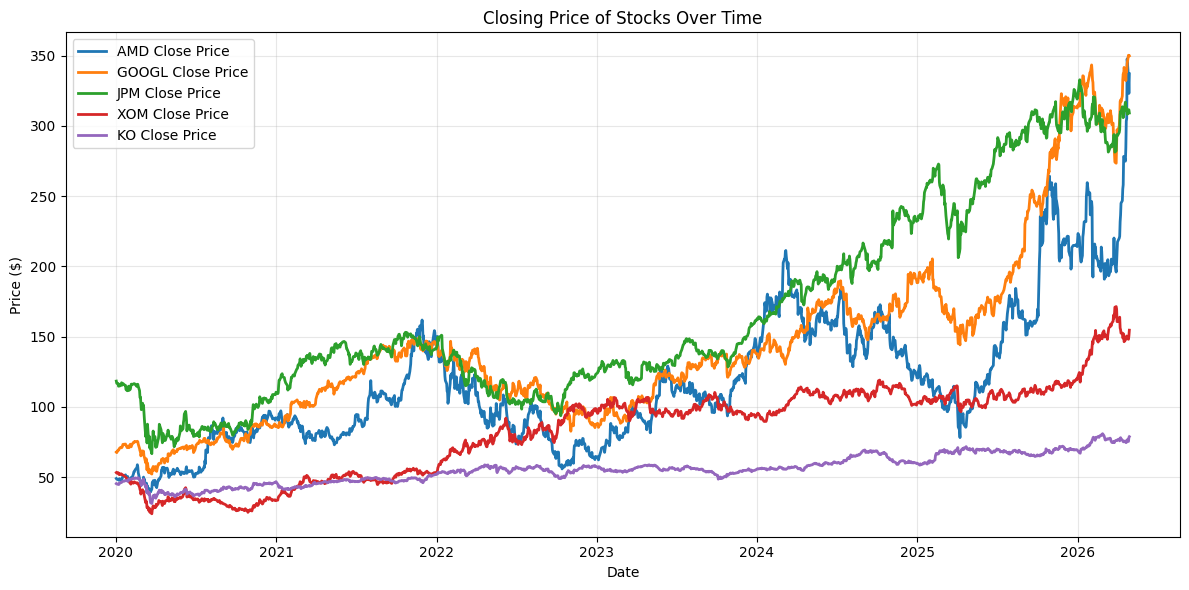

In [4]:
checks = validate_data(stock_data)
#print(checks) # print the checks to see what issues were found in the data.
cleaned_data = clean_data(stock_data, checks_dict=checks)
save_data(cleaned_data, filename='cleaned_portfolio_data.csv') # save the cleaned data to a csv file for later use.

# Plots (for some visualisation of how the adjusted closing prices vs time plots look):
print("Plot 1: Single Stock Plot (AMD) - Close Price vs Time")
plot_single_stock(cleaned_data, 'AMD') # single stock plot example post cleaning
print("Plot 2: All Stocks Plot - Close Price vs Time")
plot_stocks(cleaned_data) # plot of all stocks post cleaning.